# Séance 1 : Fondations Computationnelles — Python pour Mathématiciens

**Objectifs** :
- Prendre en main Python pour l'implémentation d'algorithmes mathématiques.
- Implémenter l'algorithme d'Euclide étendu et le crible d'Ératosthène.
- Mesurer et analyser la complexité algorithmique.

---

## 1. Préparation de l'environnement

Exécutez la cellule suivante pour importer les bibliothèques nécessaires.

In [10]:
import timeit
import matplotlib.pyplot as plt
import math

%matplotlib inline

## 2. Algorithme d'Euclide étendu

### Version récursive

Rappel : l'algorithme retourne $(d, u, v)$ tel que $d = a u + b v = \mathrm{pgcd}(a,b)$.

In [11]:
def euclide_etendu_rec(a, b):
    """
    Algorithme d'Euclide étendu (version récursive).
    Retourne (pgcd, u, v) avec a*u + b*v = pgcd.
    """
    if b == 0:
        return (a, 1, 0)
    else:
        d, u1, v1 = euclide_etendu_rec(b, a % b)
        u = v1
        v = u1 - (a // b) * v1
        return (d, u, v)

In [12]:
# Test rapide
a, b = 240, 46
d, u, v = euclide_etendu_rec(a, b)
print(f"pgcd({a}, {b}) = {d}")
print(f"{a}*{u} + {b}*{v} = {a*u + b*v}")

pgcd(240, 46) = 2
240*-9 + 46*47 = 2


### Version itérative (à compléter)

**Exercice** : Implémentez ci-dessous une version itérative de l'algorithme d'Euclide étendu. Vous pouvez utiliser une boucle `while` et mettre à jour les coefficients.

In [13]:
def euclide_etendu_iter(a, b):
    """
    Version itérative de l'algorithme d'Euclide étendu.
    """
    #initialisation 
    u0, u1=1, 0
    v0, v1=0, 1
    #si b=0, on a pgcd(a, b)= a = a*(1)+(0)*(0)
    if b==0:
       return(a, u0, v0)
    while b!=0:
        #calcul du quotient de la division euclidienne de a par b et son reste r
        q= a//b
        r= a-b*q
      
        #mis à jour des coefficients 
        u0, u1= u1, u0- q*u1
        v0, v1= v1, v0- q*v1
        #mis a jours de a et b
        a= b
        b= r
    return(a, u0, v0)

In [14]:
# Test de votre version itérative
d, u, v = euclide_etendu_iter(240, 46)
assert d == 2 and 240*u + 46*v == 2
print("Test réussi !")

Test réussi !


## 3. Crible d'Ératosthène

### Version de base

In [15]:
def eratosthene(n):
    """
    Retourne la liste des nombres premiers <= n.
    """
    if n < 2:
        return 0
    est_premier = [True] * (n+1)
    est_premier[0] = est_premier[1] = False
    for p in range(2, int(n**0.5) + 1):
        if est_premier[p]:
            for multiple in range(p*p, n+1, p):
                est_premier[multiple] = False
    return [i for i, prime in enumerate(est_premier) if prime]

In [16]:
# Test
print(eratosthene(10))


[2, 3, 5, 7]


### Version optimisée (nombres impairs uniquement)

**Exercice** : Modifiez le crible pour ne traiter que les nombres impairs (sauf 2).

In [17]:
def eratosthene_opt(n):
    """
    Crible optimisé pour ne parcourir que les impairs.
    """
 
    if n < 2:
        return []
    if n==2:
        return [2]
    # On ne crée un tableau que pour les nombres impairs
    # Taille : (n//2)+ 1
    taille = (n//2) + 1
    est_premier =[True] * taille
    for i in range (1, int(n**0.5)//2+1):
        if est_premier[i]:
            #on calcule la valeur réelle  du nombre p: p= 2*i + 1
            p= 2 * i + 1
            #on marque les multiples de p à partir de  p*p
            #l'index correspondant à p*p est p*p//2
            start = (p*p)// 2
            est_premier[start::p] = [False] * ((taille - 1 - start)// p+1)
    # On construit la liste : 2 + tous les (2i + 1) qui sont True
    premiers= [2] + [2 *i + 1 for i in range(1, taille) if est_premier[i]]
    return premiers       

In [18]:
# Test
print(eratosthene_opt((10)))

[2, 3, 5, 7, 11]


## 4. Analyse de complexité empirique

Nous allons mesurer le temps d'exécution du crible pour différentes valeurs de $n$.

In [6]:
def mesurer_temps(fonction, n, repetitions=5):
    """
    Mesure le temps moyen d'exécution de fonction(n) sur 'repetitions' exécutions.
    """
    timer = timeit.Timer(lambda: fonction(n))
    temps = timer.timeit(number=repetitions)
    return temps / repetitions

In [19]:
valeurs_n = [10**i for i in range(3, 8)]  # 10^3 à 10^7
temps_base = []
temps_opt = []

for n in valeurs_n:
    t_base = mesurer_temps(eratosthene, n, repetitions=3)
    t_opt = mesurer_temps(eratosthene_opt, n, repetitions=3)  # décommentez quand votre fonction est prête
    temps_base.append(t_base)
    temps_opt.append(t_opt)
    print(f"n = {n:7d} : temps base = {t_base:.4f} s")

n =    1000 : temps base = 0.0003 s
n =   10000 : temps base = 0.0035 s
n =  100000 : temps base = 0.0356 s
n = 1000000 : temps base = 0.2534 s
n = 10000000 : temps base = 3.1225 s


### Visualisation

On souhaite vérifier que le temps est proportionnel à $n \log \log n$.

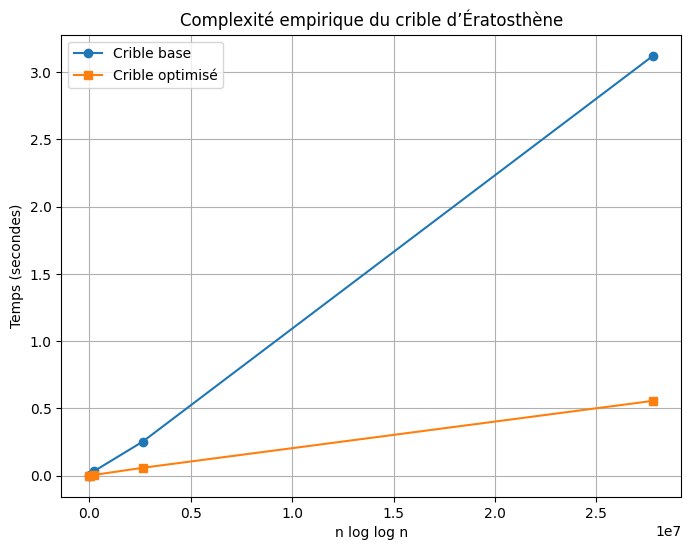

In [20]:
n_loglog = [n * math.log(math.log(n)) if n>2 else 0 for n in valeurs_n]

plt.figure(figsize=(8,6))
plt.plot(n_loglog, temps_base, 'o-', label='Crible base')
plt.plot(n_loglog, temps_opt, 's-', label='Crible optimisé')  # à décommenter
plt.xlabel('n log log n')
plt.ylabel('Temps (secondes)')
plt.title('Complexité empirique du crible d’Ératosthène')
plt.legend()
plt.grid(True)
plt.show()

## 5. Conclusion et rendu

- Assurez-vous que votre notebook contient **toutes** les fonctions demandées (versions récursive et itérative d'Euclide étendu, crible optimisé).
- Ajoutez des commentaires expliquant vos choix d'implémentation.
- Exportez ce notebook au format `.ipynb` et commitez-le dans votre dépôt GitHub.

**Rappel** : Vous pouvez utiliser l'IA comme assistant, mais vous devez comprendre chaque ligne de code et être capable de l'expliquer.